# Part 0: Load in Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import localcider
from localcider.sequenceParameters import SequenceParameters
import re
import math
import scipy
from scipy.stats import ks_2samp
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
import pathlib
from matplotlib import font_manager
from scipy.stats import fisher_exact


# Setup the fonts
fonts_path = pathlib.Path.home().joinpath('fonts') # i.e. `~/fonts` (update as needed)
font_filename = 'ARIAL.TTF'
font_path = fonts_path.joinpath(font_filename)
print(font_path)

font_manager.fontManager.addfont(str(font_path))
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['pdf.fonttype'] = 42 # Makes text editiable
plt.rcParams['ps.fonttype'] = 42

COLOR_MAP = dict()
COLOR_MAP['A']         = '#8c8c8c'
COLOR_MAP['CHNQST']    = '#077a15'
COLOR_MAP['DE']        = '#e23a36'
COLOR_MAP['FWY']       = '#f58220'
COLOR_MAP['G']         = '#86bd8d'
COLOR_MAP['ILMV']      = '#231f20'
COLOR_MAP['KR']        = '#1725c2'
COLOR_MAP['P']         = '#c25fc9'


# Using the global color map, we convert the colormap of amino acid
# groups, to a map against individual amino acids. This
# serves as our internal color map which is used for styling.
aacolor_map=dict()
for amino_acids in COLOR_MAP:
    for amino_acid in amino_acids:
        aacolor_map[amino_acid] = COLOR_MAP[amino_acids]

/home/research/kiersten.ruff/fonts/ARIAL.TTF


# Part 1: Load in  data
** If have ran this once just skip to 1.6

## 1.1 - Load in all orthologous data

In [7]:
orthdf=pd.read_excel('full_human_proteome_evolution/all_human_IDR_seqs_and_orthologs_w_zscores_clusters.xlsx')
print(orthdf)

        Unnamed: 0         Genes     Uniprot Uniprot w Num  Start Pos  \
0             1292        DNAJC3      Q13217      Q13217_1        450   
1            20055        Dnajc3      Q91YW3      Q91YW3_1        450   
2             9353        Dnajc3      Q9R0T3      Q9R0T3_1        450   
3            16195        DNAJC3      Q27968      Q27968_1        450   
4              897        DNAJC3      Q5ZI13      Q5ZI13_1        450   
...            ...           ...         ...           ...        ...   
223028       14900      F1NI88_1      F1NI88      F1NI88_1         96   
223029        9180         MZT2B  A0A151MAB3  A0A151MAB3_1        118   
223030        6698         mzt2b      Q28DB1      Q28DB1_1        101   
223031       23162          mzt2      Q6DC17      Q6DC17_1         77   
223032        9216  MAPKAPK5-AS1      Q8N8E1      Q8N8E1_1          0   

        End Pos                                           Sequence   pol-pol  \
0           481                    DPEMRKKF

## 1.2 - Get only a subset of species

In [18]:
suborthspeciesdf=orthdf[orthdf['Ortholog Species'].isin(subspecies)]
print(suborthspeciesdf)

        Unnamed: 0         Genes     Uniprot Uniprot w Num  Start Pos  \
0             1292        DNAJC3      Q13217      Q13217_1        450   
1            20055        Dnajc3      Q91YW3      Q91YW3_1        450   
3            16195        DNAJC3      Q27968      Q27968_1        450   
5             3214        dnajc3      Q28EB5      Q28EB5_1        450   
6            14402        dnajc3      Q6P0U6      Q6P0U6_1        444   
...            ...           ...         ...           ...        ...   
223027       10664          MZT2      A5PJV8      A5PJV8_1         80   
223029        9180         MZT2B  A0A151MAB3  A0A151MAB3_1        118   
223030        6698         mzt2b      Q28DB1      Q28DB1_1        101   
223031       23162          mzt2      Q6DC17      Q6DC17_1         77   
223032        9216  MAPKAPK5-AS1      Q8N8E1      Q8N8E1_1          0   

        End Pos                                           Sequence   pol-pol  \
0           481                    DPEMRKKF

## 1.3 - Add IDR Length and whether IDR, N-terminus, or C-terminus

In [19]:
suborthdf=suborthspeciesdf.copy()

coff=10

idrlength=[]
idrposition=[]
for s in range(0,len(suborthdf)):
    print(s)
    idrlength.append(suborthdf['End Pos'].tolist()[s]-suborthdf['Start Pos'].tolist()[s])
    if suborthdf['Start Pos'].tolist()[s]<coff and suborthdf['End Pos'].tolist()[s]>suborthdf['Full Protein Length'].tolist()[s]-coff:
        idrposition.append('IDR')
    elif suborthdf['Start Pos'].tolist()[s]<coff and suborthdf['End Pos'].tolist()[s]<=suborthdf['Full Protein Length'].tolist()[s]-coff:
        idrposition.append('N-terminal IDR')
    elif suborthdf['Start Pos'].tolist()[s]>=coff and suborthdf['End Pos'].tolist()[s]>suborthdf['Full Protein Length'].tolist()[s]-coff:
        idrposition.append('C-terminal IDR')
    else:
        idrposition.append('Linker IDR')
        
suborthdf['IDR Length']=idrlength
suborthdf['IDR Position']=idrposition

print(suborthdf)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

1867
1868
1869
1870
1871
1872
1873
1874
1875
1876
1877
1878
1879
1880
1881
1882
1883
1884
1885
1886
1887
1888
1889
1890
1891
1892
1893
1894
1895
1896
1897
1898
1899
1900
1901
1902
1903
1904
1905
1906
1907
1908
1909
1910
1911
1912
1913
1914
1915
1916
1917
1918
1919
1920
1921
1922
1923
1924
1925
1926
1927
1928
1929
1930
1931
1932
1933
1934
1935
1936
1937
1938
1939
1940
1941
1942
1943
1944
1945
1946
1947
1948
1949
1950
1951
1952
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047
2048
2049
2050
2051
2052
2053
2054
2055
2056
2057
2058
2059
2060
2061
2062
2063
2064
2065
2066


3512
3513
3514
3515
3516
3517
3518
3519
3520
3521
3522
3523
3524
3525
3526
3527
3528
3529
3530
3531
3532
3533
3534
3535
3536
3537
3538
3539
3540
3541
3542
3543
3544
3545
3546
3547
3548
3549
3550
3551
3552
3553
3554
3555
3556
3557
3558
3559
3560
3561
3562
3563
3564
3565
3566
3567
3568
3569
3570
3571
3572
3573
3574
3575
3576
3577
3578
3579
3580
3581
3582
3583
3584
3585
3586
3587
3588
3589
3590
3591
3592
3593
3594
3595
3596
3597
3598
3599
3600
3601
3602
3603
3604
3605
3606
3607
3608
3609
3610
3611
3612
3613
3614
3615
3616
3617
3618
3619
3620
3621
3622
3623
3624
3625
3626
3627
3628
3629
3630
3631
3632
3633
3634
3635
3636
3637
3638
3639
3640
3641
3642
3643
3644
3645
3646
3647
3648
3649
3650
3651
3652
3653
3654
3655
3656
3657
3658
3659
3660
3661
3662
3663
3664
3665
3666
3667
3668
3669
3670
3671
3672
3673
3674
3675
3676
3677
3678
3679
3680
3681
3682
3683
3684
3685
3686
3687
3688
3689
3690
3691
3692
3693
3694
3695
3696
3697
3698
3699
3700
3701
3702
3703
3704
3705
3706
3707
3708
3709
3710
3711


KeyboardInterrupt: 

## 1.4 - Filter for the given IDR lengths and min inter clust distances

In [63]:
minidrlength=50
minidrlinkerlength=70
mininterclustdist=1.5

suborthcoffdf=suborthdf.copy()
suborthcoffdf=suborthcoffdf[suborthcoffdf['IDR Length']>=minidrlength]
suborthcoffdf=suborthcoffdf[ (suborthcoffdf['IDR Length']>=minidrlinkerlength) | (suborthcoffdf['IDR Position'].isin(['IDR','N-terminal IDR','C-terminal IDR'])) ]
suborthcoffdf=suborthcoffdf[suborthcoffdf['Min Inter Clust Dist']>=mininterclustdist]
print(suborthcoffdf.isnull().any())
suborthcoffdf = suborthcoffdf.fillna('')
print(suborthcoffdf)

Unnamed: 0              False
Genes                   False
Uniprot                 False
Uniprot w Num           False
Start Pos               False
                        ...  
Full Protein Length     False
Cluster Number          False
Min Inter Clust Dist    False
IDR Length              False
IDR Position            False
Length: 104, dtype: bool
        Unnamed: 0         Genes     Uniprot Uniprot w Num  Start Pos  \
23            9167         Cgnl1      Q6AW69      Q6AW69_5        414   
35           14540         CGNL1      G5E5V6      G5E5V6_4        410   
46            6280         CGNL1  A0A151M9V8  A0A151M9V8_3       1230   
48            3222         cgnl1  A0A6I8PZJ7  A0A6I8PZJ7_2        211   
52            7127         cgnl1      F1R1I5      F1R1I5_3         92   
...            ...           ...         ...           ...        ...   
223024       11176         MZT2B      Q6NZ67      Q6NZ67_1         81   
223027       10664          MZT2      A5PJV8      A5PJV8_1   

In [64]:
humantmpdf=suborthcoffdf[suborthcoffdf['Ortholog Species']=='sapiens']
print(humantmpdf)

        Unnamed: 0         Genes Uniprot Uniprot w Num  Start Pos  End Pos  \
77           14163        NBPF7P  P0C2Y1      P0C2Y1_2        174      254   
110           3732         OTUD3  Q5T2D3      Q5T2D3_1          0       50   
111           3733         OTUD3  Q5T2D3      Q5T2D3_2        301      387   
156          18861        VANGL1  Q8TAA9      Q8TAA9_1          0       91   
164           8098          UBN2  Q6ZU65      Q6ZU65_1          0      134   
...            ...           ...     ...           ...        ...      ...   
222969       19804         BTBD8  Q9UPP5      Q9UPP5_8        761      905   
222971       19806         BTBD8  Q9UPP5     Q9UPP5_10       1134     1251   
223017         164       ARIH2OS  Q8N7S6      Q8N7S6_1          0      100   
223024       11176         MZT2B  Q6NZ67      Q6NZ67_1         81      158   
223032        9216  MAPKAPK5-AS1  Q8N8E1      Q8N8E1_1          0      139   

                                                 Sequence   pol

## 1.5 - Save dataframe so that way can load faster next time

In [65]:
suborthcoffdf.to_excel('all_human_IDR_seqs_8_orthologs_w_zscores_clusters_IDR_length_location_IDRs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.xlsx')

## 1.6 - Load in subset orthologous data

In [2]:
minidrlength=50
minidrlinkerlength=70
mininterclustdist=1.5

suborthcoffdf=pd.read_excel('data/all_human_IDR_seqs_8_orthologs_w_zscores_clusters_IDR_length_location_IDRs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.xlsx')
print(suborthcoffdf)

specieslist=['sapiens','musculus','norvegicus','taurus','gallus','mississippiensis','tropicalis','rerio','melanogaster','elegans','crassa','cerevisiae','discoideum','thaliana']
subspecies=[]
for s in specieslist:
    if s in suborthcoffdf['Ortholog Species'].tolist():
        subspecies.append(s)
print(subspecies)

       Unnamed: 0  Unnamed: 0.1         Genes     Uniprot Uniprot w Num  \
0              23          9167         Cgnl1      Q6AW69      Q6AW69_5   
1              35         14540         CGNL1      G5E5V6      G5E5V6_4   
2              46          6280         CGNL1  A0A151M9V8  A0A151M9V8_3   
3              48          3222         cgnl1  A0A6I8PZJ7  A0A6I8PZJ7_2   
4              52          7127         cgnl1      F1R1I5      F1R1I5_3   
...           ...           ...           ...         ...           ...   
48376      223024         11176         MZT2B      Q6NZ67      Q6NZ67_1   
48377      223027         10664          MZT2      A5PJV8      A5PJV8_1   
48378      223030          6698         mzt2b      Q28DB1      Q28DB1_1   
48379      223031         23162          mzt2      Q6DC17      Q6DC17_1   
48380      223032          9216  MAPKAPK5-AS1      Q8N8E1      Q8N8E1_1   

       Start Pos  End Pos                                           Sequence  \
0            414   

## 1.7 - Load in all human accessions

In [5]:
# The initial set of accessions used to extract IDRs from
tmp=pd.read_table('../general_data/ACCESSIONS_UP000005640_9606.txt')
accs_all_human=tmp['Uniprot'].tolist()
print(len(accs_all_human))
print(len(list(set(accs_all_human))))

20882
20882


# Part 2: Get enrichement of cluster by subcellular localization and species

## 2.1 - Load in subcellular information from HPA

In [6]:
HPAtable=pd.read_table('/project/fava/work/kiersten.ruff/IDRome/2023/HPA/subcellular_location.tsv')

print(HPAtable)

tmp=HPAtable[HPAtable['Gene name']=='POLR2A']
print(tmp)

                  Gene        Gene name Reliability            Main location  \
0      ENSG00000000003           TSPAN6    Approved   Cell Junctions;Cytosol   
1      ENSG00000000457            SCYL3   Supported  Cytosol;Golgi apparatus   
2      ENSG00000000460         C1orf112    Approved             Mitochondria   
3      ENSG00000000938              FGR    Approved          Plasma membrane   
4      ENSG00000000971              CFH    Approved                 Vesicles   
...                ...              ...         ...                      ...   
13142  ENSG00000290292            HOMEZ   Supported                 Nucleoli   
13143  ENSG00000290315  ENSG00000290315    Approved      Cytosol;Nucleoplasm   
13144  ENSG00000290317  ENSG00000290317    Approved              Nucleoplasm   
13145  ENSG00000291237             SOD2   Supported             Mitochondria   
13146  ENSG00000291316  ENSG00000291316    Approved              Nucleoplasm   

             Additional location    Ext

## 2.2 - Get all unique locations

In [7]:
allloc=HPAtable['Main location'].tolist()
allens=HPAtable['Gene'].tolist()

uniqueloc=[]
for a in allloc:
    if isinstance(a,str):
        #print(a)
        tmp=a.split(';')
        #print(tmp)
        for i in tmp:
            if i not in uniqueloc:
                uniqueloc.append(i)

uniqueloc.sort(key=str.lower)            
print(uniqueloc)
print(len(uniqueloc))

print(len(allloc))
print(allloc[4980:4985])

for x in range(0,len(allloc)):
    if str(allloc[x])=='nan':
        allloc[x]='missing'
        
    
idx=[i for i, x in enumerate(allloc) if x=='missing']
print(idx)

print(allloc[4189])

['Actin filaments', 'Aggresome', 'Cell Junctions', 'Centriolar satellite', 'Centrosome', 'Cytokinetic bridge', 'Cytoplasmic bodies', 'Cytosol', 'Endoplasmic reticulum', 'Endosomes', 'Focal adhesion sites', 'Golgi apparatus', 'Intermediate filaments', 'Kinetochore', 'Lipid droplets', 'Lysosomes', 'Microtubule ends', 'Microtubules', 'Midbody', 'Midbody ring', 'Mitochondria', 'Mitotic chromosome', 'Mitotic spindle', 'Nuclear bodies', 'Nuclear membrane', 'Nuclear speckles', 'Nucleoli', 'Nucleoli fibrillar center', 'Nucleoli rim', 'Nucleoplasm', 'Peroxisomes', 'Plasma membrane', 'Rods & Rings', 'Vesicles']
34
13147
['Cytosol;Vesicles', 'Centrosome;Cytosol', 'Cytosol;Nucleoplasm', 'Nucleoplasm', 'Vesicles']
[4189]
missing


## 2.3 - Get accession for each location

In [8]:
# Load in mapping of accessions to ensemble
ens2uni=pd.read_table('../general_data/HPA/ENSEMBL_to_Uniprot_location_proteins_202312_no_duplicates.tsv')

unimap=ens2uni['Uniprot'].tolist()
ensmap=ens2uni['ENSEMBL'].tolist()
# mapping is bad for POLR2A so add it 
unimap.append('P24928')
ensmap.append('ENSG00000181222')

# make sure have all maps and then remove duplicates
#ens2uniold=pd.read_excel('/project/fava/work/kiersten.ruff/IDRome/2023/HPA/ENSEMBL_to_Uniprot_location_proteins.xlsx')
#mytest=pd.concat([ens2uni,ens2uniold]).drop_duplicates(keep=False)
#print(mytest)
#mytest.to_csv('/project/fava/work/kiersten.ruff/IDRome/2023/HPA/ENSEMBL_to_Uniprot_differences.txt', sep='\t', index=False)
#hi

uniquelocacc=[[] for x in range(len(uniqueloc))]
mappedaccs=[]
count=0
for f in range(0,len(accs_all_human)):
    if accs_all_human[f] in unimap:
        idx=unimap.index(accs_all_human[f])
        if ensmap[idx] in allens:
            # Gets all accessions that can be mapped to HPA
            count=count+1
            mappedaccs.append(accs_all_human[f])
            
            # find index of ensembl accession in hpa data
            idx2=allens.index(ensmap[idx])
            
            for a in range(0,len(uniqueloc)):
                if uniqueloc[a] in allloc[idx2]:
                    if accs_all_human[f] not in uniquelocacc[a]:
                        uniquelocacc[a].append(accs_all_human[f])
                        #print(mygenes[f])
                        #print(subaccsNODIST[f])
                        #print(allloc[idx2])
                        #print(idx)
                        #hi

print(len(accs_all_human))
print('Number of mapped accessions '+str(count))
#print(uniquelocacc)

20882
Number of mapped accessions 12887


## 2.4 - Get subcellular location enrichment by GIN type

### Get if any of the human mapped proteins are in the location - this is what is used in paper!!

In [19]:
numkclusts=max(suborthcoffdf['Cluster Number'].tolist())+1

pvalsbylocation=np.zeros((len(subspecies),numkclusts,len(uniqueloc)))
pvalsbylocationlog=np.zeros((len(subspecies),numkclusts,len(uniqueloc)))
oddsratiobylocation=np.zeros((len(subspecies),numkclusts,len(uniqueloc)))

#sapienstmpdf=suborthcoffdf[suborthcoffdf['Ortholog Species']=='sapiens']

for o in range(0,len(subspecies)):
    currspeciestmpdf=suborthcoffdf[suborthcoffdf['Ortholog Species']==subspecies[o]]
    currspeciesnoduptmpdf=currspeciestmpdf.drop_duplicates(subset=['Uniprot w Num'])
    print(subspecies[o]+': '+str(len(currspeciesnoduptmpdf)))

    subclusters=currspeciesnoduptmpdf['Cluster Number'].tolist()
    subaccswnums=currspeciesnoduptmpdf['Uniprot w Num'].tolist()
    
    subaccs=[]
    for i in range(0,len(subaccswnums)):
        tmpdf=currspeciestmpdf[currspeciestmpdf['Uniprot w Num']==subaccswnums[i]]
        subaccs.append(tmpdf['Sapiens Uniprot'].tolist())
    print(len(subaccs))
    
    for a in [25,26,29]:#range(0,len(uniqueloc)):
        print(uniqueloc[a])
        sumallidrs=0
        for c in range(0,numkclusts):
            print(subspecies[o]+' Cluster_'+str(c))
            midx = [i for i, x in enumerate(subclusters) if x == c]

            topaccs=[]
            for i in midx:
                topaccs.append(subaccswnums[i])

            print('Number of IDRs: '+str(len(topaccs)))

            # For each location determine if that feature is enriched there
            subfeatureyes=0
            subfeatureno=0
            restfeatureyes=0
            restfeatureno=0
            for s in range(0,len(subaccs)):
                if len(set(subaccs[s]).intersection(set(mappedaccs)))>0:
                    if len(set(subaccs[s]).intersection(set(uniquelocacc[a])))>0:
                        if subaccswnums[s] in topaccs:
                            subfeatureyes=subfeatureyes+1
                            sumallidrs=sumallidrs+1
                        else:
                            subfeatureno=subfeatureno+1
                    else:
                        if subaccswnums[s] in topaccs:
                            restfeatureyes=restfeatureyes+1
                        else:
                            restfeatureno=restfeatureno+1

            print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

            # defining the table
            if subfeatureyes+restfeatureyes>0:
                data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
                print(data)
                # One-sided greater used to test if greater occurrence in nucleolus
                res = fisher_exact(data, alternative='greater')
                print(res[1])
                pvalsbylocation[o,c,a]=res[1]
                pvalsbylocationlog[o,c,a]=-math.log10(res[1])
                oddsratiobylocation[o,c,a]=res[0]


        print('Number of IDRs in '+uniqueloc[a]+' '+str(subfeatureyes+subfeatureno))
        print(sumallidrs)


print(pvalsbylocation)

sapiens: 8560
8560
Nuclear speckles
sapiens Cluster_0
Number of IDRs: 244
6619
[[9, 311], [183, 6116]]
0.5873566373924187
sapiens Cluster_1
Number of IDRs: 313
6619
[[17, 303], [242, 6057]]
0.12208773485744746
sapiens Cluster_2
Number of IDRs: 101
6619
[[6, 314], [65, 6234]]
0.12744030716451782
sapiens Cluster_3
Number of IDRs: 399
6619
[[13, 307], [315, 5984]]
0.8104749454866672
sapiens Cluster_4
Number of IDRs: 328
6619
[[15, 305], [241, 6058]]
0.25589877174827397
sapiens Cluster_5
Number of IDRs: 179
6619
[[9, 311], [131, 6168]]
0.23559277044555
sapiens Cluster_6
Number of IDRs: 462
6619
[[12, 308], [364, 5935]]
0.9577468761266394
sapiens Cluster_7
Number of IDRs: 255
6619
[[8, 312], [197, 6102]]
0.7825080758157684
sapiens Cluster_8
Number of IDRs: 114
6619
[[2, 318], [93, 6206]]
0.9485606702299798
sapiens Cluster_9
Number of IDRs: 399
6619
[[12, 308], [303, 5996]]
0.8427836347814145
sapiens Cluster_10
Number of IDRs: 183
6619
[[3, 317], [157, 6142]]
0.9857177931517224
sapiens Clust

5745
[[17, 274], [219, 5235]]
0.08870506795680619
musculus Cluster_2
Number of IDRs: 78
5745
[[5, 286], [57, 5397]]
0.20397505067193777
musculus Cluster_3
Number of IDRs: 359
5745
[[9, 282], [279, 5175]]
0.9613192326873576
musculus Cluster_4
Number of IDRs: 215
5745
[[9, 282], [164, 5290]]
0.5169147740663064
musculus Cluster_5
Number of IDRs: 107
5745
[[5, 286], [83, 5371]]
0.46266990353048776
musculus Cluster_6
Number of IDRs: 415
5745
[[11, 280], [332, 5122]]
0.9665741717006832
musculus Cluster_7
Number of IDRs: 215
5745
[[9, 282], [172, 5282]]
0.5725985363730798
musculus Cluster_8
Number of IDRs: 77
5745
[[3, 288], [65, 5389]]
0.6774560254033891
musculus Cluster_9
Number of IDRs: 350
5745
[[12, 279], [291, 5163]]
0.8509845104406695
musculus Cluster_10
Number of IDRs: 174
5745
[[5, 286], [145, 5309]]
0.8845702431206015
musculus Cluster_11
Number of IDRs: 135
5745
[[6, 285], [113, 5341]]
0.5647185781628599
musculus Cluster_12
Number of IDRs: 236
5745
[[10, 281], [202, 5252]]
0.6392856

5812
[[2, 279], [64, 5467]]
0.83627920978394
taurus Cluster_3
Number of IDRs: 313
5812
[[9, 272], [253, 5278]]
0.8953554912541244
taurus Cluster_4
Number of IDRs: 280
5812
[[12, 269], [221, 5310]]
0.4536513795193681
taurus Cluster_5
Number of IDRs: 138
5812
[[5, 276], [114, 5417]]
0.6894908508522768
taurus Cluster_6
Number of IDRs: 420
5812
[[10, 271], [330, 5201]]
0.9718941919712389
taurus Cluster_7
Number of IDRs: 214
5812
[[8, 273], [175, 5356]]
0.6670919455577129
taurus Cluster_8
Number of IDRs: 99
5812
[[3, 278], [81, 5450]]
0.7800588691209986
taurus Cluster_9
Number of IDRs: 310
5812
[[14, 267], [248, 5283]]
0.3884724168568942
taurus Cluster_10
Number of IDRs: 177
5812
[[3, 278], [154, 5377]]
0.9840554814286167
taurus Cluster_11
Number of IDRs: 109
5812
[[2, 279], [94, 5437]]
0.9508174148377843
taurus Cluster_12
Number of IDRs: 192
5812
[[15, 266], [157, 5374]]
0.01874009291556637
taurus Cluster_13
Number of IDRs: 281
5812
[[10, 271], [230, 5301]]
0.7327259282469145
taurus Cluste

2743
[[8, 138], [107, 2490]]
0.2664846820320376
mississippiensis Cluster_5
Number of IDRs: 46
2743
[[1, 145], [39, 2558]]
0.8896344338498182
mississippiensis Cluster_6
Number of IDRs: 194
2743
[[7, 139], [163, 2434]]
0.8136555939683232
mississippiensis Cluster_7
Number of IDRs: 116
2743
[[2, 144], [98, 2499]]
0.9740115705305945
mississippiensis Cluster_8
Number of IDRs: 17
2743
[[3, 143], [13, 2584]]
0.04967375121258685
mississippiensis Cluster_9
Number of IDRs: 183
2743
[[5, 141], [162, 2435]]
0.9509461271166096
mississippiensis Cluster_10
Number of IDRs: 84
2743
[[2, 144], [76, 2521]]
0.9272548068369736
mississippiensis Cluster_11
Number of IDRs: 34
2743
[[0, 146], [32, 2565]]
1.0
mississippiensis Cluster_12
Number of IDRs: 130
2743
[[5, 141], [110, 2487]]
0.7440416883745622
mississippiensis Cluster_13
Number of IDRs: 117
2743
[[5, 141], [98, 2499]]
0.6504757922516999
mississippiensis Cluster_14
Number of IDRs: 73
2743
[[7, 139], [64, 2533]]
0.08062241936693534
mississippiensis Clust

2374
Nuclear speckles
tropicalis Cluster_0
Number of IDRs: 42
2040
[[5, 119], [34, 1882]]
0.08390616497684926
tropicalis Cluster_1
Number of IDRs: 80
2040
[[5, 119], [67, 1849]]
0.44766299212763433
tropicalis Cluster_2
Number of IDRs: 9
2040
[[0, 124], [7, 1909]]
1.0
tropicalis Cluster_3
Number of IDRs: 118
2040
[[5, 119], [98, 1818]]
0.7640568669093364
tropicalis Cluster_4
Number of IDRs: 59
2040
[[3, 121], [50, 1866]]
0.6357737831402334
tropicalis Cluster_5
Number of IDRs: 21
2040
[[3, 121], [13, 1903]]
0.06868076507792173
tropicalis Cluster_6
Number of IDRs: 166
2040
[[3, 121], [127, 1789]]
0.9890848531379269
tropicalis Cluster_7
Number of IDRs: 88
2040
[[3, 121], [78, 1838]]
0.8817383685420312
tropicalis Cluster_8
Number of IDRs: 10
2040
[[0, 124], [8, 1908]]
1.0
tropicalis Cluster_9
Number of IDRs: 159
2040
[[8, 116], [130, 1786]]
0.6119221379967787
tropicalis Cluster_10
Number of IDRs: 75
2040
[[1, 123], [63, 1853]]
0.983072386288627
tropicalis Cluster_11
Number of IDRs: 29
2040


4737
[[0, 256], [11, 4470]]
1.0
rerio Cluster_3
Number of IDRs: 365
4737
[[14, 242], [303, 4178]]
0.8239876893326143
rerio Cluster_4
Number of IDRs: 113
4737
[[3, 253], [97, 4384]]
0.9139037079677504
rerio Cluster_5
Number of IDRs: 70
4737
[[7, 249], [59, 4422]]
0.06375082033465274
rerio Cluster_6
Number of IDRs: 393
4737
[[19, 237], [318, 4163]]
0.4586931125794357
rerio Cluster_7
Number of IDRs: 211
4737
[[9, 247], [179, 4302]]
0.6962183867961993
rerio Cluster_8
Number of IDRs: 25
4737
[[1, 255], [21, 4460]]
0.706261684699119
rerio Cluster_9
Number of IDRs: 337
4737
[[15, 241], [267, 4214]]
0.565996135293774
rerio Cluster_10
Number of IDRs: 150
4737
[[6, 250], [126, 4355]]
0.726991538364392
rerio Cluster_11
Number of IDRs: 121
4737
[[8, 248], [101, 4380]]
0.23498116553117118
rerio Cluster_12
Number of IDRs: 222
4737
[[11, 245], [189, 4292]]
0.5218300810932837
rerio Cluster_13
Number of IDRs: 196
4737
[[6, 250], [164, 4317]]
0.9057184192738894
rerio Cluster_14
Number of IDRs: 133
4737


2990
[[8, 269], [80, 2633]]
0.5781124527678004
melanogaster Cluster_8
Number of IDRs: 45
2990
[[8, 269], [37, 2676]]
0.051315756988335
melanogaster Cluster_9
Number of IDRs: 142
2990
[[7, 270], [123, 2590]]
0.9651653135947751
melanogaster Cluster_10
Number of IDRs: 39
2990
[[2, 275], [36, 2677]]
0.8802646045087489
melanogaster Cluster_11
Number of IDRs: 228
2990
[[16, 261], [200, 2513]]
0.8658262055782682
melanogaster Cluster_12
Number of IDRs: 134
2990
[[19, 258], [111, 2602]]
0.028282171194823017
melanogaster Cluster_13
Number of IDRs: 85
2990
[[8, 269], [69, 2644]]
0.42211214758613835
melanogaster Cluster_14
Number of IDRs: 61
2990
[[3, 274], [52, 2661]]
0.8969401018127956
melanogaster Cluster_15
Number of IDRs: 28
2990
[[2, 275], [23, 2690]]
0.6886106741975839
melanogaster Cluster_16
Number of IDRs: 174
2990
[[16, 261], [143, 2570]]
0.4017319455836573
melanogaster Cluster_17
Number of IDRs: 94
2990
[[9, 268], [74, 2639]]
0.36107243789891186
melanogaster Cluster_18
Number of IDRs: 1

584
[[2, 70], [34, 478]]
0.9518666094488393
cerevisiae Cluster_8
Number of IDRs: 2
584
[[0, 72], [2, 510]]
1.0
cerevisiae Cluster_9
Number of IDRs: 46
584
[[4, 68], [38, 474]]
0.7879033281771197
cerevisiae Cluster_10
Number of IDRs: 11
584
[[3, 69], [8, 504]]
0.14342487677780064
cerevisiae Cluster_11
Number of IDRs: 26
584
[[8, 64], [17, 495]]
0.006910061294970911
cerevisiae Cluster_12
Number of IDRs: 27
584
[[2, 70], [23, 489]]
0.8377744989357907
cerevisiae Cluster_13
Number of IDRs: 6
584
[[0, 72], [6, 506]]
1.0
cerevisiae Cluster_14
Number of IDRs: 9
584
[[2, 70], [7, 505]]
0.3066833115259488
cerevisiae Cluster_15
Number of IDRs: 5
584
[[0, 72], [4, 508]]
1.0
cerevisiae Cluster_16
Number of IDRs: 23
584
[[2, 70], [19, 493]]
0.7559915389014633
cerevisiae Cluster_17
Number of IDRs: 27
584
[[2, 70], [25, 487]]
0.8687279842515658
cerevisiae Cluster_18
Number of IDRs: 68
584
[[5, 67], [60, 452]]
0.9275701989773228
cerevisiae Cluster_19
Number of IDRs: 48
584
[[5, 67], [41, 471]]
0.694878

## 2.5 - Save p-values

In [20]:
whichlocs=[25,26,29]

for l in range(0,len(whichlocs)):
    #np.savetxt('data/each_orthologous_IDR_once_subcellular_location_HPA_enrichment_8_orthologs_in_IDRs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'.txt', pvalsbylocationlog[:,:,whichlocs[l]])
    #np.savetxt('data/each_orthologous_IDR_once_subcellular_location_HPA_enrichment_8_orthologs_in_IDRs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'_odds_ratio.txt', oddsratiobylocation[:,:,whichlocs[l]])

## 2.6 - Plot GIN cluster enrichment by ortholog and location

            Species        18        14         26        11        28
0           sapiens  4.768443  1.492427  15.843961  0.089178  0.902528
1          musculus  2.885706  0.911936   6.621029  0.248168  2.150854
2            taurus  2.132675  2.248232   9.903598  0.021903  0.828919
3  mississippiensis  1.425210  1.093544   5.256590 -0.000000  0.072231
4        tropicalis  0.256193  0.062655   5.629390  0.107937  0.679964
5             rerio  0.530691  0.367116  13.661191  0.628967  0.045428
6      melanogaster  0.258276  0.047237   5.905931  0.062569  0.165808
7        cerevisiae  0.032653  0.513310   0.449969  2.160518  1.128657
            Species         7        18        12         23        25
0           sapiens  2.629869  2.026687  0.420412  16.434301  0.524041
1          musculus  1.359807  3.438305  1.564556  15.314296  2.036748
2            taurus  2.313560  2.582414  2.078474  18.170688  0.479897
3  mississippiensis  2.409069  1.711373  1.213160   8.248007  0.172457
4     

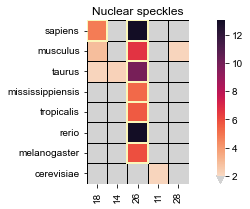

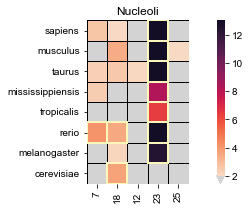

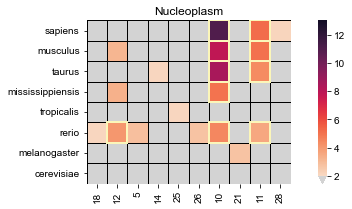

In [21]:
myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

mfmypalette=['#fbf6b9']

whichlocs=[25,26,29]

for l in range(0,len(whichlocs)):
    tmp=np.loadtxt('data/each_orthologous_IDR_once_subcellular_location_HPA_enrichment_8_orthologs_in_IDRs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'.txt')

    fig, ax = plt.subplots(figsize=(10,3))
    pvalsbylocationlog2=tmp
    pvalsbylocationlog2[:] = pvalsbylocationlog2[:, myclustorder]
    mymask=np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=0)
    mysubfeats=[]
    for i in range(0,len(mymask)):
        if mymask[i] == True:
            mysubfeats.append(myclustorder[i])

    sbn.heatmap(pvalsbylocationlog2[:,mymask],cmap=green,vmin=-math.log10(0.01), vmax=13, cbar_kws={'extend': 'min'}, square=True, linewidth=1,linecolor='#000000')
    plt.xticks(np.arange(0.5, len(mysubfeats), 1), mysubfeats,rotation=90) 
    plt.yticks(np.arange(0.5, len(subspecies), 1), subspecies,rotation=0) 
    plt.title(uniqueloc[whichlocs[l]])

    for i in range(0,len(pvalsbylocationlog2[:,mymask])):
        for j in range(0,len(pvalsbylocationlog2[:,mymask][0])):
            if pvalsbylocationlog2[:,mymask][i][j]> -math.log10(0.01/len(myclustorder)):
                ax.add_patch(patches.Rectangle((j, i),1,1,edgecolor=mfmypalette[0],fill=False,lw=2))
    
    #plt.savefig('Figures/2025_04/fisher_exact_test_pvals_location_heatmap_8_orthologs_idrs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'.pdf', transparent=True, bbox_inches = "tight") 
    #plt.savefig('Figures/2025_04/each_orthologous_IDR_once_fisher_exact_test_pvals_location_heatmap_8_orthologs_idrs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'_w_cutoff_divided_by_30.pdf', transparent=True, bbox_inches = "tight") 

    
    tdf1=pd.DataFrame(subspecies,columns=['Species'])
    tdf2=pd.DataFrame(pvalsbylocationlog2[:,mymask],columns=mysubfeats)
    tdf=pd.concat([tdf1,tdf2],axis=1)
    print(tdf)
    
    #tdf.to_excel('Figures/2025_04/each_orthologous_IDR_once_fisher_exact_test_pvals_location_heatmap_8_orthologs_idrs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'.xlsx')

## 2.6b - as bubble plot

            Species        18  18 Odds Ratio        14  14 Odds Ratio  \
0           sapiens  4.768443       2.864500  1.492427       1.749142   
1          musculus  2.885706       2.307911  0.911936       1.510503   
2            taurus  2.132675       2.068318  2.248232       2.082397   
3  mississippiensis  1.425210       2.048203  1.093544       1.993143   
4        tropicalis  0.256193       1.017249  0.062655       0.565270   
5             rerio  0.530691       1.206692  0.367116       1.138294   
6      melanogaster  0.258276       0.995843  0.047237       0.560289   
7        cerevisiae  0.032653       0.562189  0.513310       2.061224   

          26  26 Odds Ratio        11  11 Odds Ratio        28  28 Odds Ratio  
0  15.843961       7.315283  0.089178       0.705668  0.902528       1.532487  
1   6.621029       4.606539  0.248168       0.995063  2.150854       2.265874  
2   9.903598       5.388476  0.021903       0.414627  0.828919       1.509281  
3   5.256590       5.1

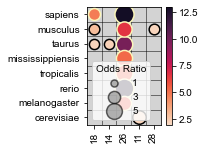

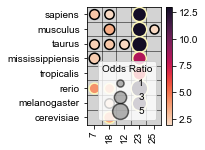

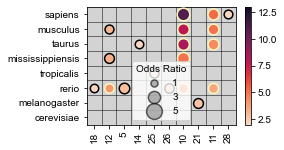

In [24]:
myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

whichlocs=[25,26,29]

for l in range(0,len(whichlocs)):
    tmp=np.loadtxt('data/each_orthologous_IDR_once_subcellular_location_HPA_enrichment_8_orthologs_in_IDRs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'.txt')
    tmpor=np.loadtxt('data/each_orthologous_IDR_once_subcellular_location_HPA_enrichment_8_orthologs_in_IDRs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'_odds_ratio.txt')
    
    dfenrichorth=pd.DataFrame()
    dfenrichorth['Species']=subspecies
    
    for i in range(0,len(myclustorder)):
        dfenrichorth[myclustorder[i]]=tmp[:,myclustorder[i]]
        dfenrichorth[str(myclustorder[i])+' Odds Ratio']=tmpor[:,myclustorder[i]]
        
    # Remove Clusters that have no significant enrichment 
    nonsigclustnum=0
    sigclustlist=[]
    cols_to_drop = []
    for col in myclustorder:
        if (dfenrichorth[col] <= -math.log10(0.01)).all(): # Check if ALL values in the column are less than x
            cols_to_drop.append(col)
            cols_to_drop.append(str(col)+' Odds Ratio')
            nonsigclustnum=nonsigclustnum+1
        else:
            sigclustlist.append(col)
            
    dfenrichorth = dfenrichorth.drop(columns=cols_to_drop)
    print(dfenrichorth)

    szscale=50
    fig, ax = plt.subplots(figsize=((len(sigclustlist))/3,len(subspecies)/3.7))
    ax.set_facecolor('lightgrey')
    for a in range(0,len(subspecies)):
        ax.plot([-0.5,len(sigclustlist)-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=-1,linewidth=0.5)
        #ax.plot([-1.5,-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=0,linewidth=0.5)
        for c in range(0,len(sigclustlist)):
            if a==0:
                ax.plot([c+0.5,c+0.5],[0.5,-1*(len(subspecies))+0.5],'-',color='black',zorder=0,linewidth=0.5)

            # Plot enrichment of IDRs of a given cluster in a ortholog
            if dfenrichorth[sigclustlist[c]].tolist()[a] > -math.log10(0.01):
                if dfenrichorth[sigclustlist[c]].tolist()[a] > -math.log10(0.01/len(myclustorder)):
                    if dfenrichorth[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]>15:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichorth[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichorth[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=1,linewidths=1.5)
                    elif dfenrichorth[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]>5:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichorth[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichorth[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=2,linewidths=1.5)
                        print(subspecies[a]+' '+str(sigclustlist[c]))
                        print(dfenrichorth[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale)
                    else:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichorth[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichorth[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=3,linewidths=1.5)                    
                else:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichorth[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichorth[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=3,linewidths=1.5)


    #plt.colorbar(myscatter,extend='min',ax=ax)
    plt.colorbar(myscatter,ax=ax)
    ax.set_yticks(np.arange(0, -1*(len(subspecies)), -1), subspecies,rotation=0) 
    ax.set_xticks(np.arange(0, len(sigclustlist), 1), sigclustlist,rotation=90) 
    ax.set_ylim([-1*(len(subspecies))+0.5,0.5])
    ax.set_xlim([-0.5,len(sigclustlist)-0.5])

    size_val_arr=np.array([1,3,5])
    for size_val, label_text in [(szscale*size_val_arr[0], "1"), (szscale*size_val_arr[1], "3"), (szscale*size_val_arr[2], "5")]:
        ax.scatter([], [], s=size_val, color='gray', edgecolor='black',linewidth=1.5, alpha=0.6, label=f'{label_text}')
        print(size_val)
    plt.legend(scatterpoints=1, frameon=True, title="Odds Ratio")    

    #plt.savefig('/project/fava/work/kiersten.ruff/Collaborations/Su/2023/Library_design/IDR_basis_set/Figures/2025_08/each_orthologous_IDR_once_fisher_exact_test_pvals_location_heatmap_8_orthologs_idrs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'_w_cutoff_divided_by_30_bubble.pdf', transparent=True, bbox_inches = "tight") 

    #print(dfenrichorth)
    #dfenrichorth.to_excel('data/each_orthologous_IDR_once_subcellular_location_HPA_enrichment_8_orthologs_in_IDRs_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_location_'+uniqueloc[whichlocs[l]]+'.xlsx')